# Valutazione del modello formale

Questo notebook analizza il comportamento del modello di scheduling policy-driven
descritto nel Capitolo 3, eseguito attraverso l'implementazione di riferimento in
Python. L'obiettivo non è misurare tempi di esecuzione — quelli dipendono
dall'infrastruttura e vengono misurati separatamente sul prototipo Kubernetes — ma
caratterizzare **quanto le politiche restringono lo spazio delle soluzioni** e
**come lo stato accumulato sui nodi ne fa evolvere l'ammissibilità**.

L'analisi è divisa in due parti, che corrispondono a due domande distinte.

**Parte I — Lo spazio delle soluzioni.** Ogni task viene valutato singolarmente su
un cluster pulito e inattivo: nessuna impronta contestuale, nessun nodo occupato,
nessuna sanificazione in corso. Quello che si misura è una proprietà della
*configurazione*: quanto le politiche `c_prop`, `c_geo` e `c_static` riducono
l'insieme dei nodi ammissibili, singolarmente e in composizione.

**Parte II — La dinamica dell'assegnazione.** Lo stesso carico viene eseguito come
sequenza ordinata, lasciando evolvere le due sole variabili di stato del sistema:
l'impronta contestuale `Λ(n)` lasciata dai task e l'occupazione dei nodi. Quello che
si misura è l'effetto dello *stato*: quanto la politica di Chinese Wall blocca, come
le strategie di sanificazione lo mitigano, e quanto la ridondanza dei nodi aiuta.

Tenere separate le due parti è ciò che permette di attribuire un risultato o alla
composizione del cluster o allo stato accumulato, invece che a una miscela
indistinguibile dei due.

## Metodologia

**Il passo come unità.** Nella Parte II un passo corrisponde a un task sottomesso.
Non è un'unità di tempo: la durata dei task e il periodo di sanificazione sono
espressi in passi, e le latenze assolute non vengono mai stimate qui. Misurare
millisecondi richiederebbe di simulare code, backoff e latenze di rete, cioè di
modellare il prototipo invece di misurarlo.

**Task bloccati.** Un task che al proprio passo non trova alcun nodo ammissibile
viene contato come bloccato e non viene riprovato. Riprovarlo introdurrebbe una
coda, che è comportamento del prototipo. Qui si misura l'ammissibilità istantanea:
se lo stato lasciato dai task precedenti consente a questo di partire.

**Ripetizioni.** Ogni configurazione è eseguita con 10 semi indipendenti, che
determinano composizione del cluster, attributi e piazzamento dei dataset, grafo dei
conflitti e ordine del batch. I grafici riportano la **mediana** fra i semi e, dove
utile, la banda fra minimo e massimo: le distribuzioni sono spesso asimmetriche e la
media sarebbe fuorviante.

**Isolamento delle variabili.** Ogni ambito attinge da un flusso pseudocasuale
indipendente, quindi cambiare il numero di task non altera il cluster e cambiare la
densità di conflitto non altera i dataset. Ogni esperimento fa variare un solo asse
rispetto a una configurazione di riferimento comune.

In [56]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS = Path(".tmp/results")
FIGURES = Path(".tmp/figures")
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (7.2, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

TRANSLATION_CAUSES = {"auth", "geo_empty", "static_empty"}


# Carica un file di risultati e vi aggiunge le colonne derivate usate nei grafici.
def load(name):
    df = pd.read_csv(RESULTS / f"{name}.csv")
    if "cause" not in df.columns:
        return df

    df["rifiutato_in_traduzione"] = df.cause.isin(TRANSLATION_CAUSES)
    for cause in ("prop", "geo", "static", "wall", "capacity", "sanitizing",
                  "geo_empty", "static_empty"):
        df[f"causa_{cause}"] = df.cause == cause

    inspected = ~df.rifiutato_in_traduzione
    for col, src in (("frazione_prop", "n_after_prop"),
                     ("frazione_geo", "n_after_geo"),
                     ("frazione_static", "n_after_static"),
                     ("frazione_ammissibili", "n_admissible")):
        df[col] = np.where(inspected, df[src] / df.n_nodes, np.nan)

    df["richiede_statici"] = df.n_static_datasets > 0
    return df


# Aggrega per configurazione e seme: una riga per ogni run.
def per_seed(df, keys, metrics):
    return df.groupby(keys + ["seed"], observed=True).agg(**metrics).reset_index()


# Mediana fra i semi, con minimo e massimo per rappresentare la dispersione.
def mediana_e_banda(per_seed_df, keys, column):
    g = per_seed_df.groupby(keys, observed=True)[column]
    return g.agg(mediana="median", minimo="min", massimo="max").reset_index()


def salva(fig, nome):
    fig.tight_layout()
    fig.savefig(FIGURES / f"{nome}.pdf")
    fig.savefig(FIGURES / f"{nome}.png", dpi=160)

---

# Parte I — Lo spazio delle soluzioni

Le politiche del modello agiscono in due punti diversi della pipeline. Alcune
rifiutano il task **in traduzione**, prima ancora che un nodo venga esaminato: è il
caso di `geo*(t) = ∅`, quando i dataset richiesti sono soggetti a giurisdizioni
senza alcuna intersezione, e dell'intersezione vuota dei nodi che ospitano
localmente i dataset statici. Altre agiscono **in filtraggio**, escludendo nodi
uno per uno.

La distinzione conta perché le due situazioni si mitigano in modo opposto: un
rifiuto in traduzione dipende dalla richiesta e non si risolve aggiungendo nodi,
mentre un'esclusione in filtraggio dipende dalla composizione del cluster.

## Quanto ciascuna politica restringe l'insieme dei nodi ammissibili

Le politiche vengono valutate in ordine fisso — prima `c_prop`, poi `c_geo`, poi
`c_static` — e ogni nodo escluso viene attribuito alla prima politica che non
soddisfa. Il conteggio dopo ciascuna politica è quindi il numero di nodi
sopravvissuti a quella e a tutte le precedenti, e la sequenza si legge come un
imbuto.

L'esperimento fa variare la **cardinalità di `req(t)`**, il numero di dataset
richiesti da ciascun task, su tre composizioni di cluster: uno *piatto*, in cui
tutti i nodi offrono il livello massimo di ogni proprietà; uno *stratificato*, con
le classi distribuite uniformemente sul reticolo; e uno *realistico*, sbilanciato
verso i livelli bassi con pochi nodi di fascia alta.

Il numero di dataset è la variabile interessante perché il requisito effettivo
`β*(t)` è il minimo maggiorante fra il requisito del task e quello di tutti i
dataset che usa: più dataset richiede, più il requisito effettivo sale, anche se
l'issuer non ha chiesto nulla di particolare.

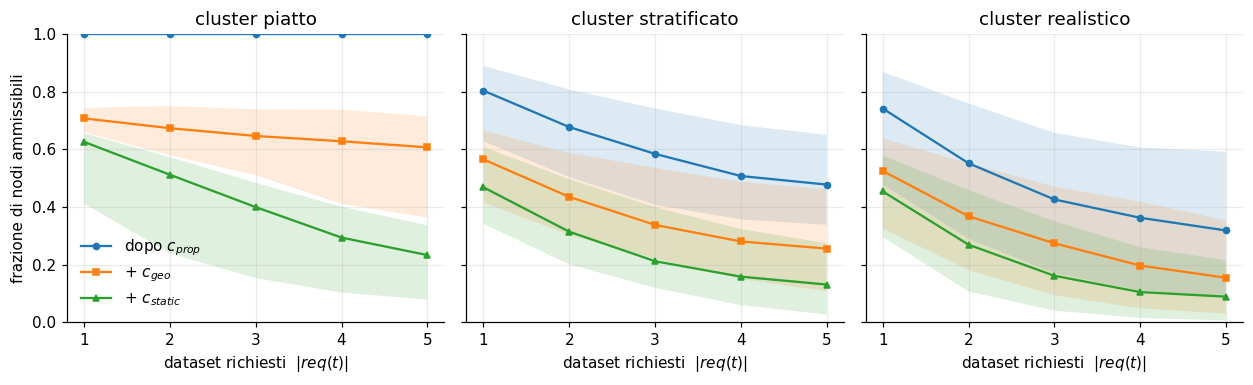

                      prop    geo  static
template   req_size                      
flat       1         1.000  0.708   0.626
           2         1.000  0.674   0.512
           3         1.000  0.647   0.400
           4         1.000  0.628   0.294
           5         1.000  0.607   0.233
realistic  1         0.742  0.525   0.454
           2         0.552  0.368   0.269
           3         0.426  0.274   0.161
           4         0.363  0.197   0.105
           5         0.319  0.154   0.089
stratified 1         0.804  0.565   0.468
           2         0.678  0.435   0.314
           3         0.584  0.338   0.212
           4         0.508  0.280   0.158
           5         0.478  0.256   0.131


In [57]:
d = load("policy_funnel_tasks")
etichette = {"flat": "piatto", "stratified": "stratificato", "realistic": "realistico"}

ps = per_seed(d[~d.rifiutato_in_traduzione], ["template", "req_size"], dict(
    prop=("frazione_prop", "mean"),
    geo=("frazione_geo", "mean"),
    static=("frazione_static", "mean"),
))

fig, assi = plt.subplots(1, 3, figsize=(11.5, 3.6), sharey=True)
for ax, template in zip(assi, ["flat", "stratified", "realistic"]):
    sub = ps[ps.template == template]
    for colonna, nome, stile in (("prop", "dopo $c_{prop}$", "-o"),
                                 ("geo", "+ $c_{geo}$", "-s"),
                                 ("static", "+ $c_{static}$", "-^")):
        b = mediana_e_banda(sub, ["req_size"], colonna)
        ax.plot(b.req_size, b.mediana, stile, label=nome, markersize=4)
        ax.fill_between(b.req_size, b.minimo, b.massimo, alpha=0.15)
    ax.set_title(f"cluster {etichette[template]}")
    ax.set_xlabel("dataset richiesti  $|req(t)|$")
    ax.set_xticks([1, 2, 3, 4, 5])
assi[0].set_ylabel("frazione di nodi ammissibili")
assi[0].set_ylim(0, 1)
assi[0].legend(frameon=False)
salva(fig, "imbuto_politiche")
plt.show()

print(ps.groupby(["template", "req_size"])[["prop", "geo", "static"]].median().round(3))

**Risultato.** Il pool si restringe in modo marcato al crescere del numero di
dataset richiesti, e la caduta è dovuta soprattutto all'amplificazione di `β*(t)`:
anche nel cluster piatto, dove `c_prop` non può escludere nessuno per costruzione,
si passa dal 55% al 15% di nodi superstiti fra uno e cinque dataset, per effetto
delle sole `c_geo` e `c_static`. Nel cluster realistico, dove anche `c_prop` morde,
con cinque dataset sopravvive circa il 6% dei nodi.

Il contributo delle tre politiche non è uniforme: `c_geo` è quella che taglia di
più in tutti gli scenari, perché `geo*(t)` è un'intersezione che si restringe a
ogni dataset aggiunto, mentre `c_static` incide in proporzione alla quota di
dataset statici nel carico.

La lettura progettuale è che il numero di dataset per task è una leva di
dimensionamento tanto quanto l'eterogeneità del cluster: task che aggregano molte
sorgenti sono strutturalmente più difficili da collocare, indipendentemente da
quanto è grande il cluster.

## Residenza dei dati statici e fattore di replica

I dataset marcati come statici non possono essere trasferiti: il task deve
raggiungerli dove si trovano. Quando un task ne richiede più d'uno, i nodi
candidati sono quelli che li ospitano **tutti** localmente, cioè l'intersezione
degli insiemi `λ(d)`. Se l'intersezione è vuota, il task viene rifiutato in
traduzione, prima che qualunque nodo venga esaminato.

Si fanno variare due parametri: la frazione di dataset statici nella popolazione e
il numero di nodi su cui ciascun dataset è replicato. Il primo determina quanto
spesso il vincolo si applica, il secondo quanto è probabile che un'intersezione non
vuota esista.

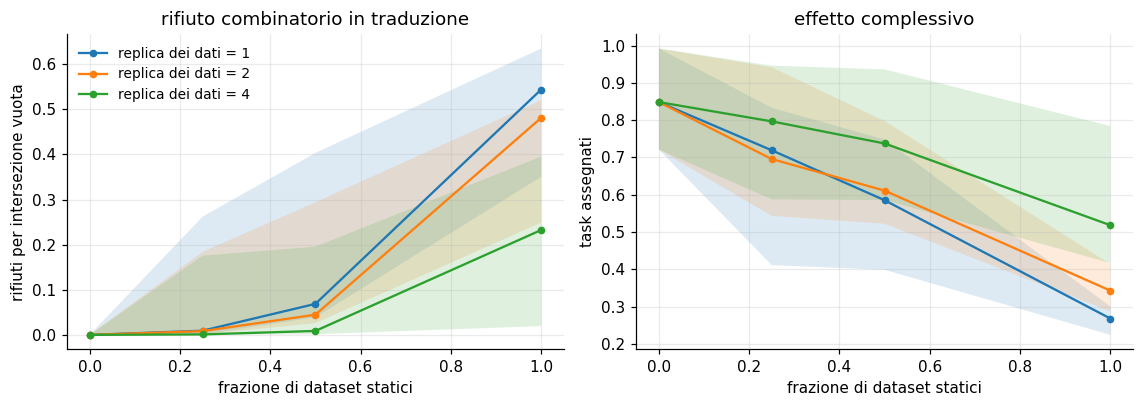

                                  intersezione_vuota  assegnati
static_fraction data_replication                               
0.00            1                              0.000      0.848
                2                              0.000      0.848
                4                              0.000      0.848
0.25            1                              0.009      0.719
                2                              0.008      0.696
                4                              0.001      0.796
0.50            1                              0.069      0.585
                2                              0.045      0.611
                4                              0.009      0.737
1.00            1                              0.544      0.268
                2                              0.481      0.342
                4                              0.232      0.518


In [58]:
d = load("static_data_tasks")
ps = per_seed(d, ["static_fraction", "data_replication"], dict(
    intersezione_vuota=("causa_static_empty", "mean"),
    assegnati=("assigned", "mean"),
))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.8), sharex=True)
for replica in sorted(ps.data_replication.unique()):
    sub = ps[ps.data_replication == replica]
    b = mediana_e_banda(sub, ["static_fraction"], "intersezione_vuota")
    ax1.plot(b.static_fraction, b.mediana, "-o", markersize=4,
             label=f"replica dei dati = {replica}")
    ax1.fill_between(b.static_fraction, b.minimo, b.massimo, alpha=0.15)
    b = mediana_e_banda(sub, ["static_fraction"], "assegnati")
    ax2.plot(b.static_fraction, b.mediana, "-o", markersize=4,
             label=f"replica dei dati = {replica}")
    ax2.fill_between(b.static_fraction, b.minimo, b.massimo, alpha=0.15)

ax1.set_xlabel("frazione di dataset statici"); ax2.set_xlabel("frazione di dataset statici")
ax1.set_ylabel("rifiuti per intersezione vuota")
ax2.set_ylabel("task assegnati")
ax1.legend(frameon=False, fontsize=9)
ax1.set_title("rifiuto combinatorio in traduzione")
ax2.set_title("effetto complessivo")
salva(fig, "dati_statici")
plt.show()

print(ps.groupby(["static_fraction", "data_replication"])[
    ["intersezione_vuota", "assegnati"]].median().round(3))

**Risultato.** Il rifiuto per intersezione vuota cresce rapidamente con la quota di
dataset statici e si attenua in modo altrettanto marcato con la replica dei dati.
Nel caso estremo in cui tutti i dataset sono statici e ciascuno risiede su un solo
nodo, oltre metà dei task viene rifiutata in traduzione; replicando gli stessi dati
su quattro nodi la quota scende a circa un quinto, e la frazione di task assegnati
raddoppia.

L'andamento non è lineare: passare da una a due repliche produce un guadagno
modesto, mentre il salto a quattro è sostanziale. La ragione è combinatoria — la
probabilità che `k` insiemi casuali di dimensione `r` abbiano intersezione non
vuota cresce più che linearmente in `r` — e la conseguenza pratica è che una
replica minimale dei dati statici non basta: serve un fattore di replica
confrontabile con il numero tipico di dataset statici combinati in un singolo task.

## L'effetto dell'ingrandimento del cluster

Aggiungere nodi è la risposta istintiva a un sistema che rifiuta troppi task. Per
verificarne l'efficacia il cluster viene costruito come un *template* replicato un
numero crescente di volte: la composizione — proporzioni di classi di proprietà e
di località — resta identica, cambia solo la dimensione. Ogni effetto osservato è
quindi attribuibile alla scala e non a un cambio di composizione.

Il confronto è fra due modalità di replica. Nella prima i dati seguono i nodi: ogni
replica del template ospita gli stessi dataset del template originale. Nella
seconda i nodi si replicano ma i dati restano dove sono, che è la situazione
realistica quando si aggiunge capacità di calcolo senza rimettere mano allo storage.

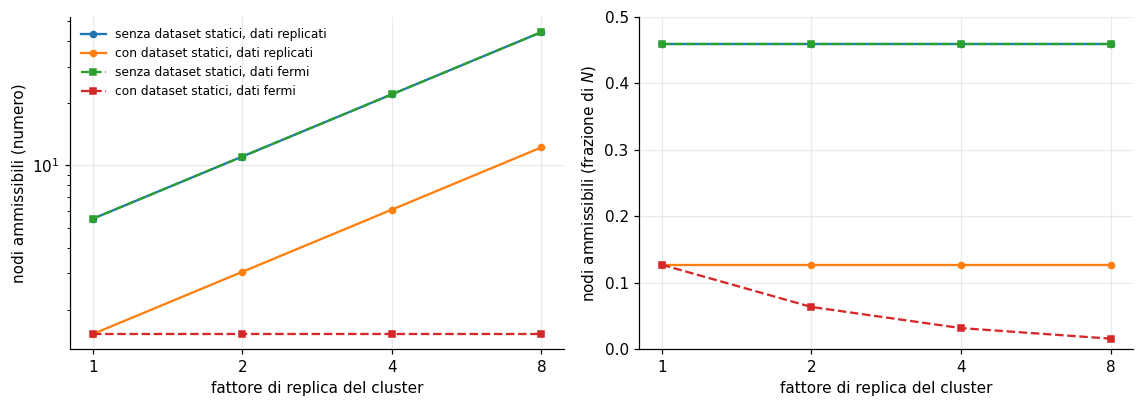

                                                        nodi  \
data_follows_nodes richiede_statici replication_factor         
False              False            1                   12.0   
                                    2                   24.0   
                                    4                   48.0   
                                    8                   96.0   
                   True             1                   12.0   
                                    2                   24.0   
                                    4                   48.0   
                                    8                   96.0   
True               False            1                   12.0   
                                    2                   24.0   
                                    4                   48.0   
                                    8                   96.0   
                   True             1                   12.0   
                                    2   

In [59]:
d = load("scale_tasks")
d = d[~d.rifiutato_in_traduzione]

ps = per_seed(d, ["data_follows_nodes", "richiede_statici", "replication_factor"], dict(
    ammissibili_assoluti=("n_admissible", "mean"),
    ammissibili_frazione=("frazione_ammissibili", "mean"),
    nodi=("n_nodes", "mean"),
))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.8))
for segue in (True, False):
    for statici in (False, True):
        sub = ps[(ps.data_follows_nodes == segue) & (ps.richiede_statici == statici)]
        if sub.empty:
            continue
        nome = ("con dataset statici" if statici else "senza dataset statici")
        nome += ", dati replicati" if segue else ", dati fermi"
        stile = "-o" if segue else "--s"
        b = mediana_e_banda(sub, ["replication_factor"], "ammissibili_assoluti")
        ax1.plot(b.replication_factor, b.mediana, stile, markersize=4, label=nome)
        b = mediana_e_banda(sub, ["replication_factor"], "ammissibili_frazione")
        ax2.plot(b.replication_factor, b.mediana, stile, markersize=4, label=nome)

for ax, etichetta in ((ax1, "nodi ammissibili (numero)"),
                      (ax2, "nodi ammissibili (frazione di $N$)")):
    ax.set_xlabel("fattore di replica del cluster")
    ax.set_ylabel(etichetta)
    ax.set_xscale("log", base=2); ax.set_xticks([1, 2, 4, 8])
    ax.set_xticklabels([1, 2, 4, 8])
ax1.set_yscale("log")
ax2.set_ylim(0, 0.5)
ax1.legend(frameon=False, fontsize=8)
salva(fig, "scala_cluster")
plt.show()

print(ps.groupby(["data_follows_nodes", "richiede_statici", "replication_factor"])[
    ["nodi", "ammissibili_assoluti", "ammissibili_frazione"]].median().round(2))

**Risultato.** Per i task che non richiedono dataset statici, il numero di nodi
ammissibili cresce proporzionalmente alla dimensione del cluster e la frazione resta
costante intorno al 43%: `c_prop` e `c_geo` sono invarianti alla scala, perché
replicare il template replica anche i nodi di ogni classe e di ogni località.

Per i task che richiedono dataset statici il comportamento dipende interamente da
dove stanno i dati. Se i dati seguono i nodi, il pool cresce insieme al cluster e la
frazione resta costante al 16%. Se i dati restano fermi, **il numero assoluto di
nodi ammissibili non cambia**: resta bloccato intorno a due nodi mentre il cluster
passa da 12 a 96, e la frazione collassa dal 16% al 2%.

Questa è la limitazione più importante emersa dall'analisi dello spazio delle
soluzioni, ed è contro-intuitiva: la scalabilità orizzontale, che il modello propone
come mitigazione, non produce alcun beneficio per i task vincolati a dati statici a
meno che non si replichino anche i dati. È un risultato che riemergerà nella Parte
II, dove la stessa mitigazione viene valutata contro il blocco da conflitto di
interesse.

---

# Parte II — La dinamica dell'assegnazione

Nella Parte I il cluster era pulito e inattivo, e ogni task veniva valutato in
isolamento. Qui il carico viene eseguito come sequenza: ogni task assegnato deposita
la propria impronta contestuale `ctx*(t)` sul nodo che lo esegue e ne occupa uno
slot per una durata fissata.

Le due variabili di stato hanno effetti diversi. L'impronta contestuale è
**monotona crescente** e viene azzerata solo dalla sanificazione, quindi tende ad
accumularsi finché non interviene un meccanismo esterno; l'occupazione si libera da
sola alla fine di ogni task. È questa asimmetria a rendere la politica di Chinese
Wall l'unico punto del modello che può degradare progressivamente.

## Conflitti di interesse e schedulabilità

L'insieme `X_conf` delle coppie di contesti in conflitto viene generato come grafo
casuale su un insieme fisso di contesti, parametrizzato dalla **densità**: la
frazione delle coppie possibili che sono effettivamente in conflitto. Usare una
densità invece di un conteggio assoluto mantiene i risultati confrontabili al
variare del numero di contesti.

La grandezza osservata è la frazione di task bloccati **dallo stato**: task per cui
la sola configurazione del cluster avrebbe lasciato dei candidati, ma che non ne
trovano nessuno a causa delle tracce accumulate. È la metrica che isola l'effetto
della dinamica da quello della configurazione, misurato nella Parte I.

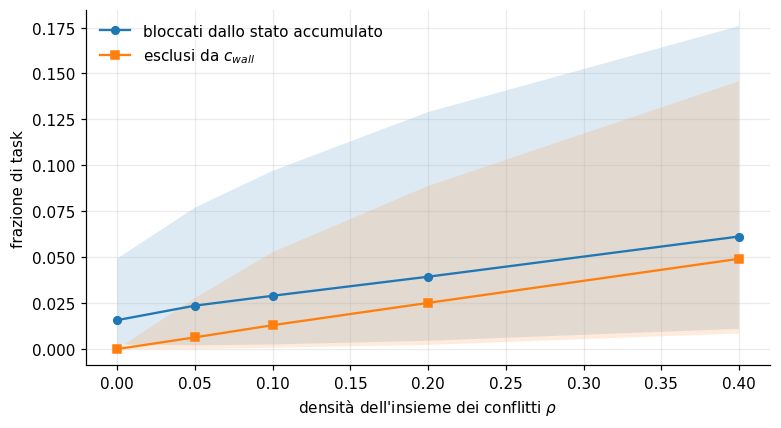

                  bloccati_da_stato  bloccati_da_wall  assegnati
conflict_density                                                
0.00                          0.016             0.000      0.789
0.05                          0.024             0.006      0.777
0.10                          0.029             0.013      0.766
0.20                          0.039             0.025      0.749
0.40                          0.061             0.049      0.723


In [60]:
d = load("conflicts_tasks")
ps = per_seed(d, ["conflict_density"], dict(
    bloccati_da_stato=("blocked_by_state", "mean"),
    bloccati_da_wall=("causa_wall", "mean"),
    assegnati=("assigned", "mean"),
))

fig, ax = plt.subplots()
for colonna, nome, stile in (("bloccati_da_stato", "bloccati dallo stato accumulato", "-o"),
                             ("bloccati_da_wall", r"esclusi da $c_{wall}$", "-s")):
    b = mediana_e_banda(ps, ["conflict_density"], colonna)
    ax.plot(b.conflict_density, b.mediana, stile, markersize=5, label=nome)
    ax.fill_between(b.conflict_density, b.minimo, b.massimo, alpha=0.15)
ax.set_xlabel(r"densità dell'insieme dei conflitti $\rho$")
ax.set_ylabel("frazione di task")
ax.legend(frameon=False)
salva(fig, "conflitti")
plt.show()

print(ps.groupby("conflict_density")[
    ["bloccati_da_stato", "bloccati_da_wall", "assegnati"]].median().round(3))

**Risultato.** La frazione di task bloccati cresce con la densità di conflitto, ma
in modo **sublineare**: passando da nessun conflitto a una densità del 40% — cioè
due coppie di contesti su cinque in conflitto fra loro, uno scenario di competizione
molto intenso — i blocchi imputabili allo stato passano dal 2% all'8%. La crescita
non è proporzionale alla densità perché la sanificazione periodica interviene a
ripulire i nodi prima che la contaminazione diventi generalizzata.

Il valore residuo del 2% in assenza di conflitti non è rumore: è il costo della
sanificazione stessa, che toglie temporaneamente nodi dall'insieme disponibile. È
un primo indizio del fatto che il meccanismo di mitigazione ha un prezzo, che il
prossimo esperimento quantifica.

## Strategie di sanificazione a confronto

Il modello prevede che l'impronta contestuale venga periodicamente azzerata, e
descrive tre modi di decidere quando farlo. Il prototipo ne implementa uno solo, la
sanificazione **periodica**: a intervalli fissi tutti i nodi che portano una traccia
vengono sanificati. Le altre due sono descritte nel modello ma non realizzate, e
questa è l'occasione per valutarle.

La strategia **a soglia** interviene solo sui nodi la cui impronta ha raggiunto una
certa cardinalità, spendendo disponibilità solo dove la contaminazione è
effettivamente ampia. La strategia **opportunistica** interviene solo sui nodi che
non stanno eseguendo nulla, sfruttando i momenti di inattività.

Il confronto va fatto su due dimensioni insieme, perché una strategia che sanifica
più spesso riduce i blocchi da conflitto ma toglie più a lungo i nodi dall'insieme
disponibile. Si misurano quindi sia i task bloccati sia la disponibilità media dei
nodi.

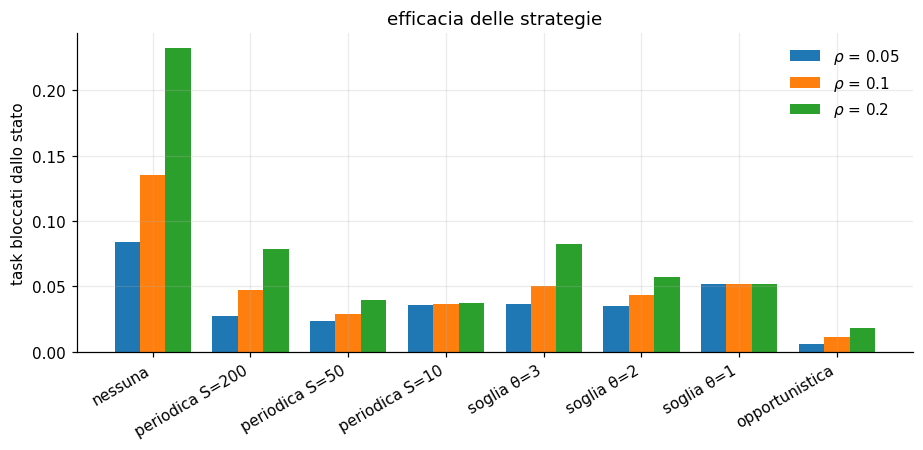

                 bloccati  disponibilita
etichetta                               
nessuna             0.232          1.000
periodica S=200     0.078          0.991
periodica S=50      0.039          0.969
periodica S=10      0.037          0.918
soglia θ=3          0.082          0.962
soglia θ=2          0.057          0.934
soglia θ=1          0.051          0.855
opportunistica      0.018          1.000


In [61]:
# Nome leggibile della strategia, che per periodica e soglia include il parametro.
def nome_strategia(riga):
    if riga.strategy == "none":
        return "nessuna"
    if riga.strategy == "opportunistic":
        return "opportunistica"
    if riga.strategy == "periodic":
        return f"periodica S={int(riga.period)}"
    return f"soglia θ={int(riga.threshold)}"


d = load("sanitization_tasks")
d["etichetta"] = d.apply(nome_strategia, axis=1)

steps = load("sanitization_steps")
steps["etichetta"] = steps.apply(nome_strategia, axis=1)

ordine = ["nessuna", "periodica S=200", "periodica S=50", "periodica S=10",
          "soglia θ=3", "soglia θ=2", "soglia θ=1", "opportunistica"]

blocchi = per_seed(d, ["etichetta", "conflict_density"], dict(
    bloccati=("blocked_by_state", "mean")))
disp = per_seed(steps, ["etichetta", "conflict_density"], dict(
    disponibili=("n_available", "mean")))
disp["disponibilita"] = disp.disponibili / 12

fig, ax = plt.subplots(figsize=(8.5, 4.2))
larghezza = 0.26
x = np.arange(len(ordine))
for i, rho in enumerate(sorted(blocchi.conflict_density.unique())):
    sub = blocchi[blocchi.conflict_density == rho]
    b = mediana_e_banda(sub, ["etichetta"], "bloccati").set_index("etichetta").reindex(ordine)
    ax.bar(x + (i - 1) * larghezza, b.mediana, larghezza, label=fr"$\rho$ = {rho}")
ax.set_xticks(x); ax.set_xticklabels(ordine, rotation=30, ha="right")
ax.set_ylabel("task bloccati dallo stato")
ax.legend(frameon=False)
ax.set_title("efficacia delle strategie")
salva(fig, "sanificazione_efficacia")
plt.show()

confronto = (blocchi[blocchi.conflict_density == 0.2].groupby("etichetta").bloccati.median()
             .to_frame("bloccati")
             .join(disp[disp.conflict_density == 0.2].groupby("etichetta").disponibilita.median()))
print(confronto.reindex(ordine).round(3))

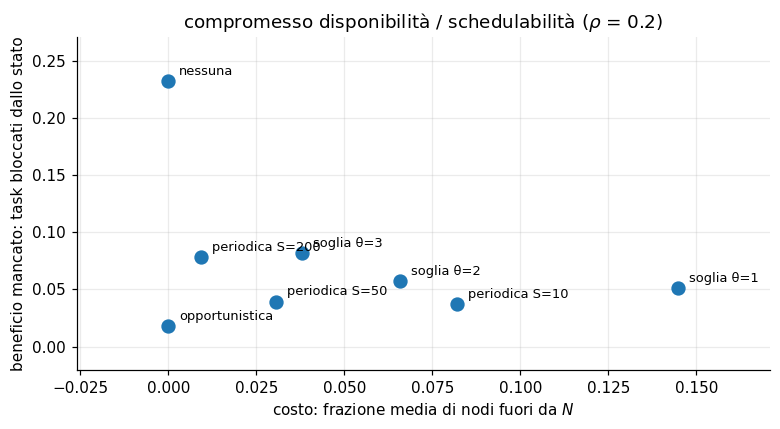

In [62]:
fig, ax = plt.subplots()
sub = confronto.reindex(ordine).dropna()
ax.scatter(1 - sub.disponibilita, sub.bloccati, s=70, zorder=3)
for nome, riga in sub.iterrows():
    ax.annotate(nome, (1 - riga.disponibilita, riga.bloccati),
                textcoords="offset points", xytext=(7, 4), fontsize=8.5)
ax.set_xlabel("costo: frazione media di nodi fuori da $N$")
ax.set_ylabel("beneficio mancato: task bloccati dallo stato")
ax.set_title(r"compromesso disponibilità / schedulabilità ($\rho$ = 0.2)")
ax.margins(0.18)
salva(fig, "sanificazione_compromesso")
plt.show()

**Risultato.** Le tre famiglie di strategie si comportano in modo nettamente
diverso, e la differenza non si vede guardando solo i blocchi.

Senza sanificazione la contaminazione è progressiva e circa un quinto dei task
risulta bloccato: è il limite superiore, e conferma che il meccanismo è necessario e
non opzionale. La sanificazione periodica riduce i blocchi in modo monotono al
ridursi del periodo, ma il guadagno si esaurisce: dimezzare ulteriormente il periodo
costa disponibilità senza migliorare in proporzione, perché i nodi sanificati troppo
spesso passano una quota crescente del tempo fuori dall'insieme disponibile.

La strategia opportunistica domina tutte le altre su entrambe le dimensioni: ottiene
il minor numero di blocchi **senza alcun costo di disponibilità**, perché sanifica
solo nodi che non stanno eseguendo nulla e che quindi non sarebbero comunque stati
sottratti a un task in corso. Il grafico del compromesso lo mostra chiaramente: è
l'unico punto nell'angolo in basso a sinistra.

La conclusione progettuale è diretta. Il prototipo implementa la strategia meno
efficiente delle tre, e adottare un innesco opportunistico — sanificare un nodo
quando non ha task attivi, invece che a intervalli fissi — migliorerebbe la
schedulabilità senza costi. È una modifica contenuta, perché il controller osserva
già i task attivi sul nodo per decidere quando completare la sanificazione.

## Ridondanza dei nodi: quando aiuta e quando no

Il modello propone la ridondanza orizzontale — più nodi equivalenti per classe e
località — come mitigazione contro il blocco da conflitto di interesse:
l'intuizione è che se un nodo è contaminato ce ne sia un altro pulito. Qui la si
verifica, riprendendo la stessa costruzione a template replicato usata nella Parte I
e le stesse due modalità, con i dati che seguono i nodi oppure restano fermi.

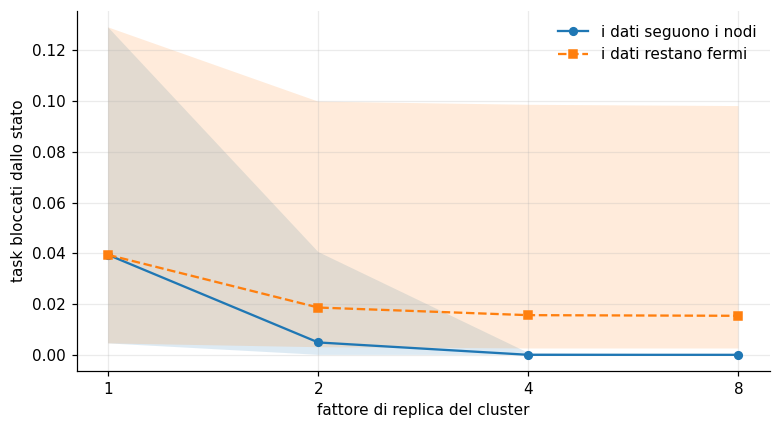

                                       bloccati   wall
data_follows_nodes replication_factor                 
False              1                      0.039  0.025
                   2                      0.019  0.012
                   4                      0.016  0.010
                   8                      0.015  0.009
True               1                      0.039  0.025
                   2                      0.005  0.002
                   4                      0.000  0.000
                   8                      0.000  0.000


In [63]:
d = load("redundancy_tasks")
ps = per_seed(d, ["data_follows_nodes", "replication_factor"], dict(
    bloccati=("blocked_by_state", "mean"),
    wall=("causa_wall", "mean"),
))

fig, ax = plt.subplots()
for segue, nome, stile in ((True, "i dati seguono i nodi", "-o"),
                           (False, "i dati restano fermi", "--s")):
    sub = ps[ps.data_follows_nodes == segue]
    b = mediana_e_banda(sub, ["replication_factor"], "bloccati")
    ax.plot(b.replication_factor, b.mediana, stile, markersize=5, label=nome)
    ax.fill_between(b.replication_factor, b.minimo, b.massimo, alpha=0.15)
ax.set_xscale("log", base=2); ax.set_xticks([1, 2, 4, 8]); ax.set_xticklabels([1, 2, 4, 8])
ax.set_xlabel("fattore di replica del cluster")
ax.set_ylabel("task bloccati dallo stato")
ax.legend(frameon=False)
salva(fig, "ridondanza")
plt.show()

print(ps.groupby(["data_follows_nodes", "replication_factor"])[
    ["bloccati", "wall"]].median().round(3))

**Risultato.** La mitigazione funziona, ma solo a una condizione. Se i dati seguono
i nodi, raddoppiare il cluster riduce i blocchi di oltre cinque volte e a un fattore
di replica quattro il blocco da conflitto di interesse **scompare del tutto**: ci
sono sempre abbastanza nodi puliti equivalenti.

Se i dati restano fermi, invece, la curva si appiattisce quasi subito: si passa dal
5.6% al 3.6% raddoppiando il cluster, e da lì in poi aggiungere nodi non produce
alcun miglioramento, nemmeno moltiplicando la dimensione per otto. Il motivo è
quello individuato nella Parte I: i task vincolati a dataset statici continuano ad
avere lo stesso, piccolo insieme di nodi candidati, e sono esattamente quelli che
restano bloccati.

Il risultato qualifica la mitigazione proposta nel modello. La ridondanza
orizzontale è efficace contro la starvation da Chinese Wall, ma è la ridondanza
**dei dati**, non quella dei nodi, a determinare fino a che punto lo sia. In un
cluster reale i due fattori vanno dimensionati insieme.

---

# Sintesi

**Sullo spazio delle soluzioni.** Le politiche di configurazione restringono il pool
in misura sostanziale e cumulativa: con cinque dataset per task sopravvive fra il 6%
e il 15% dei nodi a seconda della composizione del cluster. Il fattore dominante è
l'amplificazione del requisito effettivo `β*(t)`, che è determinato dai dati e non
dall'issuer.

**Sui dati statici.** Il rifiuto per intersezione vuota è il vincolo più severo del
modello e l'unico che nessuna quantità di nodi può risolvere da sola: aggiungere
nodi al cluster lascia invariato il numero assoluto di candidati per un task
vincolato a dati statici, a meno di replicare anche i dati. La replica dei dati
mitiga il rifiuto in modo marcato ma non lineare: servono repliche in numero
confrontabile con i dataset statici tipicamente combinati in un task.

**Sulla dinamica.** Il blocco da conflitto di interesse cresce con la densità dei
conflitti in modo sublineare finché la sanificazione interviene, e raggiunge circa
un quinto dei task se la sanificazione è assente. La strategia di innesco conta più
della frequenza: quella opportunistica domina tutte le altre su entrambe le
dimensioni misurate, ottenendo i blocchi più bassi senza alcun costo di
disponibilità dei nodi.

**Sulle mitigazioni.** La ridondanza orizzontale dei nodi elimina completamente il
blocco da conflitto di interesse, ma solo se accompagnata dalla replica dei dati;
altrimenti il beneficio si esaurisce dopo il primo raddoppio del cluster, per la
stessa ragione osservata per i dati statici.

**Limitazioni.** I risultati valgono sotto le distribuzioni sintetiche adottate, che
sono documentate nella configurazione di riferimento e vanno considerate parte delle
ipotesi. Il passo non è un'unità di tempo e nessuna latenza assoluta è stimabile da
questa analisi. La saturazione dei nodi per risorse di calcolo non è modellata: il
sistema implementato non impone limiti sul numero di task concorrenti per nodo, e la
saturazione per CPU e memoria è demandata ai meccanismi nativi di Kubernetes,
esterni al contributo di questa tesi.